<a href="https://colab.research.google.com/github/sandeepkumarkusman/celebal-excellence-internship/blob/main/week2_sandeepkumarkusman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla EV Sales & Pricing Analysis (2015–2025)


## Imports and Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded.')

All libraries loaded.


## 1. Data Loading & Cleaning


In [ ]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumn names:\n{list(df.columns)}')
df.head(10)

Dataset shape: 2640 rows x 12 columns

Column names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


In [ ]:
# missing values
null_counts = df.isnull().sum()
print('Missing values per column:')
print(null_counts)
print(f'\nTotal missing cells: {null_counts.sum()}')

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing cells: 0


In [ ]:
# duplicates
dup_count = df.duplicated().sum()
print(f'Duplicate rows found: {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed duplicates. New shape: {df.shape}')

Duplicate rows found: 0


In [ ]:
df.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


### Datetime column


In [ ]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df.sort_values(by='Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Date range: {df["Date"].min().strftime("%B %Y")} to {df["Date"].max().strftime("%B %Y")}')
df[['Date', 'Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries']].head()

Date range: January 2015 to December 2025


,Date,Year,Month,Region,Model,Estimated_Deliveries
0,2015-01-01,2015,1,Asia,Model Y,12446
1,2015-01-01,2015,1,Middle East,Model 3,11446
2,2015-01-01,2015,1,Middle East,Cybertruck,8803
3,2015-01-01,2015,1,North America,Cybertruck,6367
4,2015-01-01,2015,1,Asia,Model 3,8795


### Outlier check (IQR)
Flagging values outside Q1-1.5×IQR and Q3+1.5×IQR — not removing, just checking.


In [ ]:
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

outlier_report = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    outlier_report[col] = outlier_mask.sum()

print('Outlier counts (IQR method):')
for col, cnt in outlier_report.items():
    print(f'  {col}: {cnt} outliers ({cnt/len(df)*100:.1f}%)')

Outlier counts (IQR method):
  Estimated_Deliveries: 12 outliers (0.5%)
  Production_Units: 12 outliers (0.5%)
  Avg_Price_USD: 0 outliers (0.0%)
  Battery_Capacity_kWh: 0 outliers (0.0%)
  Range_km: 0 outliers (0.0%)
  CO2_Saved_tons: 45 outliers (1.7%)
  Charging_Stations: 0 outliers (0.0%)


### Unique categories


In [ ]:
cat_cols = ['Region', 'Model', 'Source_Type']

for col in cat_cols:
    print(f'{col} ({df[col].nunique()} unique): {sorted(df[col].unique())}')
    print()

Region (4 unique): ['Asia', 'Europe', 'Middle East', 'North America']

Model (5 unique): ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']

Source_Type (3 unique): ['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']



## 2. Exploratory Data Analysis


### Distribution of key variables


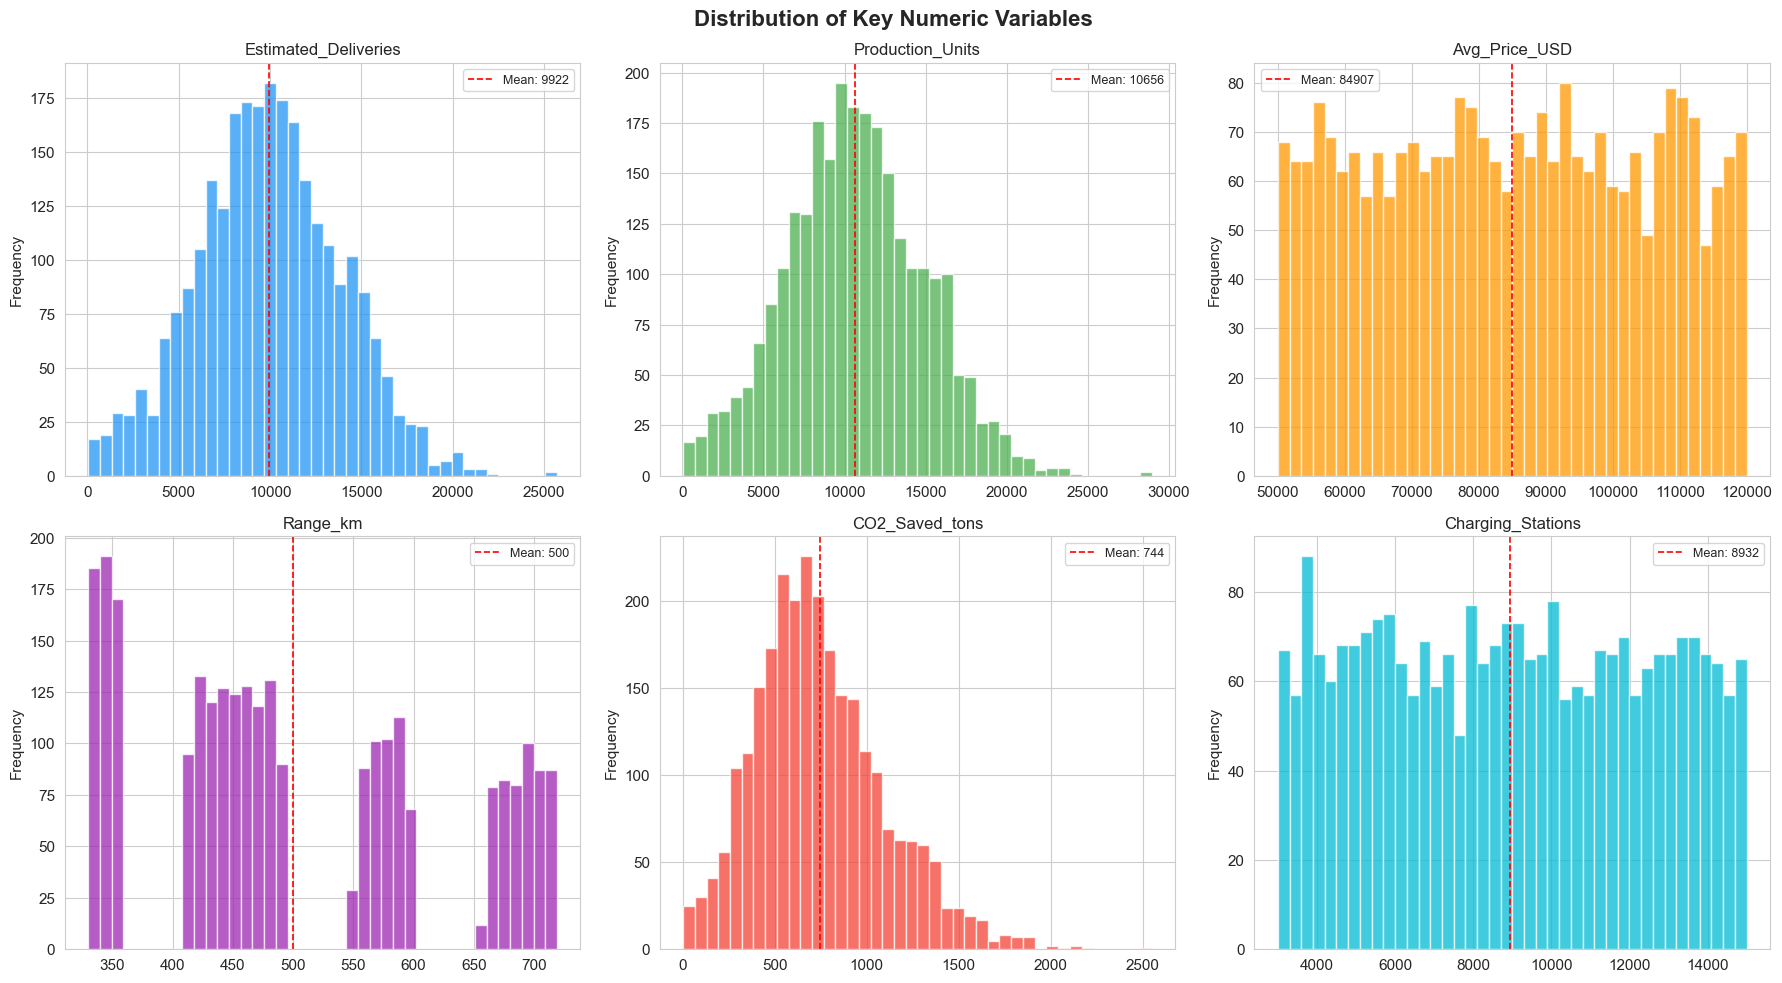

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Numeric Variables', fontsize=16, fontweight='bold')

plot_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
             'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for idx, (col, color) in enumerate(zip(plot_cols, colors)):
    ax = axes[idx // 3][idx % 3]
    ax.hist(df[col], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.0f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Boxplots


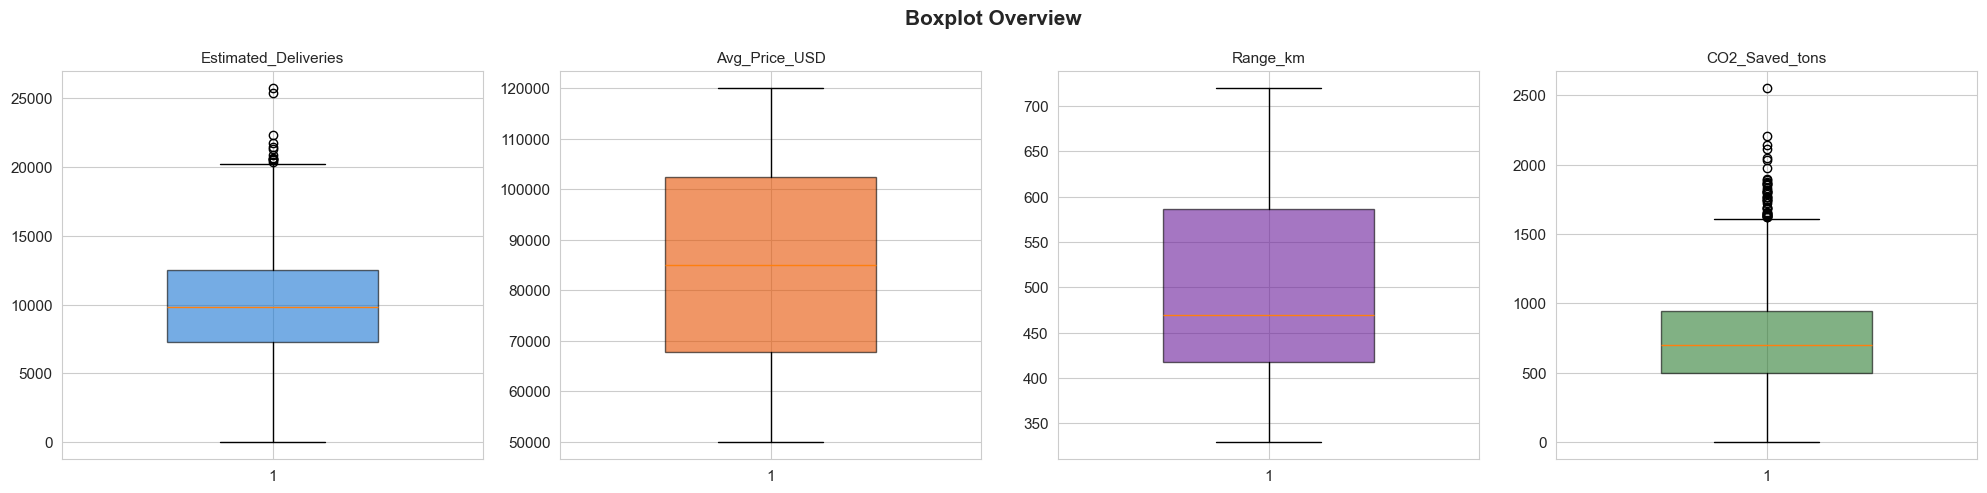

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Boxplot Overview', fontsize=15, fontweight='bold')

box_cols = ['Estimated_Deliveries', 'Avg_Price_USD', 'Range_km', 'CO2_Saved_tons']
bp_colors = ['#1976D2', '#E65100', '#6A1B9A', '#2E7D32']

for i, (col, c) in enumerate(zip(box_cols, bp_colors)):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(c)
    bp['boxes'][0].set_alpha(0.6)
    axes[i].set_title(col, fontsize=11)

plt.tight_layout()
plt.show()

### Correlation heatmap


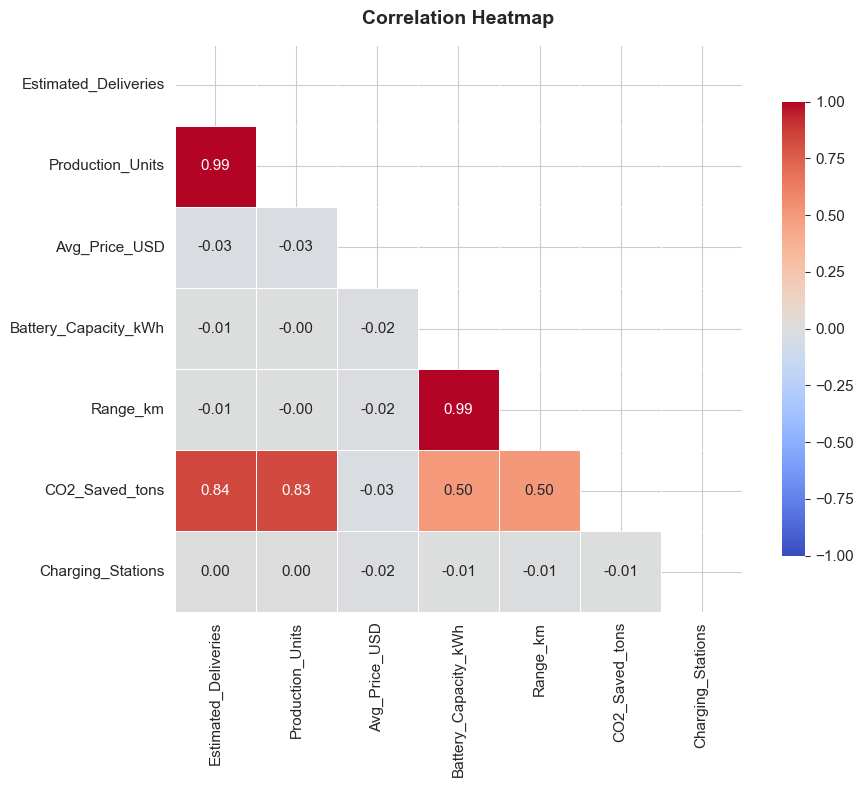

In [ ]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            square=True, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Year-over-year trends


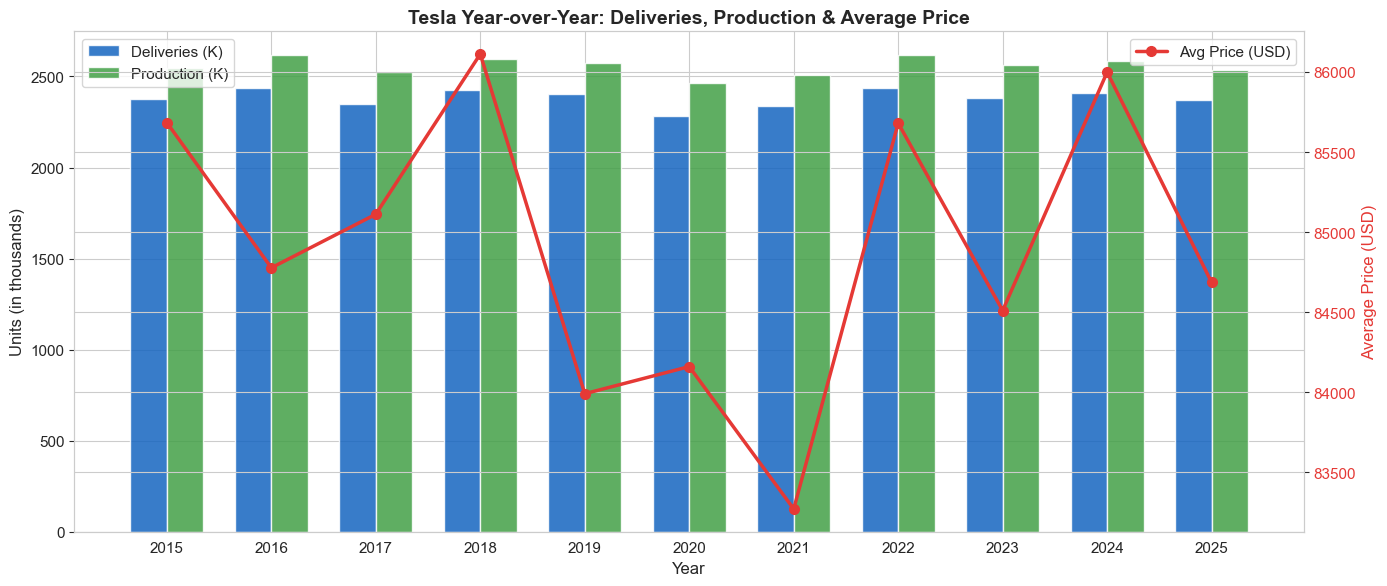

In [ ]:
yearly_agg = df.groupby('Year').agg(
    total_deliveries=('Estimated_Deliveries', 'sum'),
    total_production=('Production_Units', 'sum'),
    avg_price=('Avg_Price_USD', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

bar_width = 0.35
x = np.arange(len(yearly_agg))

bars1 = ax1.bar(x - bar_width/2, yearly_agg['total_deliveries']/1000, bar_width,
                color='#1565C0', alpha=0.85, label='Deliveries (K)')
bars2 = ax1.bar(x + bar_width/2, yearly_agg['total_production']/1000, bar_width,
                color='#43A047', alpha=0.85, label='Production (K)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Units (in thousands)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(yearly_agg['Year'])
ax1.legend(loc='upper left', fontsize=11)

ax2 = ax1.twinx()
ax2.plot(x, yearly_agg['avg_price'], color='#E53935', marker='o', linewidth=2.5,
         markersize=7, label='Avg Price (USD)')
ax2.set_ylabel('Average Price (USD)', fontsize=12, color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')
ax2.legend(loc='upper right', fontsize=11)

plt.title('Tesla Year-over-Year: Deliveries, Production & Average Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Regional breakdown


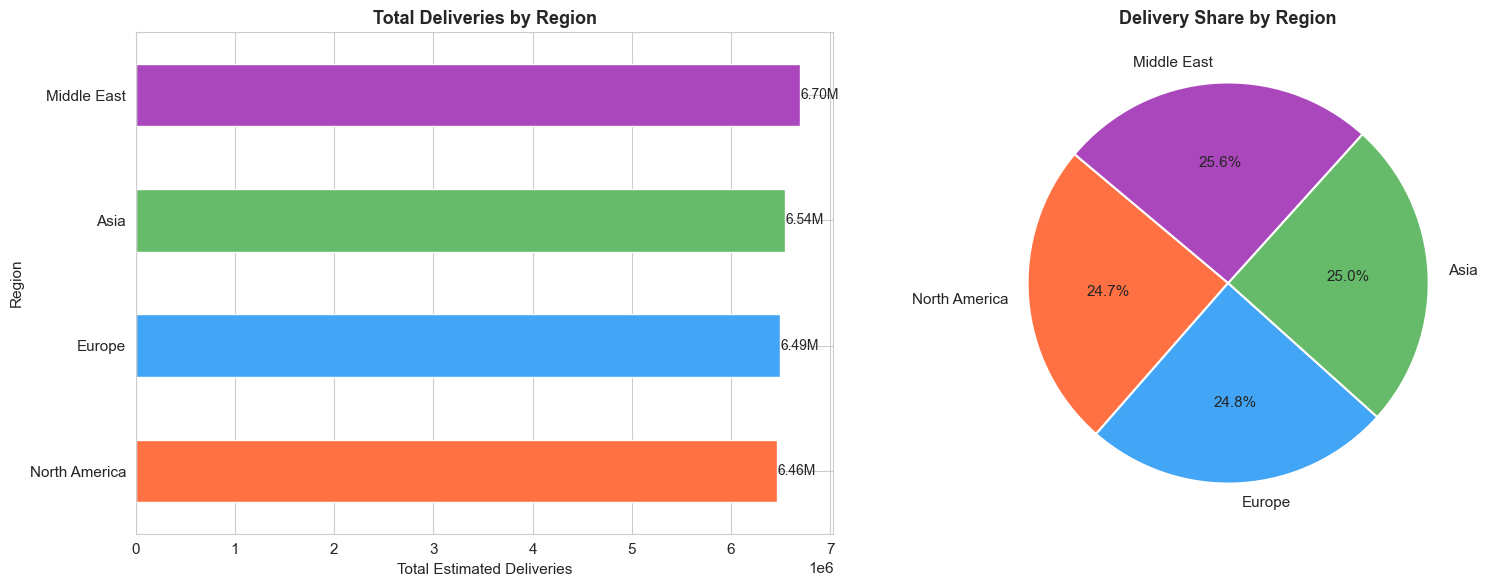

In [ ]:
region_totals = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = ['#FF7043', '#42A5F5', '#66BB6A', '#AB47BC']
region_totals.plot(kind='barh', ax=axes[0], color=region_colors, edgecolor='white')
axes[0].set_title('Total Deliveries by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Estimated Deliveries')
for i, v in enumerate(region_totals.values):
    axes[0].text(v + 5000, i, f'{v/1e6:.2f}M', va='center', fontsize=10)

axes[1].pie(region_totals.values, labels=region_totals.index, autopct='%1.1f%%',
            colors=region_colors, startangle=140, textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Delivery Share by Region', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Model-wise comparison


In [ ]:
model_stats = df.groupby('Model').agg(
    mean_deliveries=('Estimated_Deliveries', 'mean'),
    mean_price=('Avg_Price_USD', 'mean'),
    mean_range=('Range_km', 'mean'),
    total_deliveries=('Estimated_Deliveries', 'sum')
).round(1)

model_stats

,mean_deliveries,mean_price,mean_range,total_deliveries
Model,,,,
Cybertruck,9677.6,84498.9,499.8,5109779
Model 3,10079.4,84528.0,503.2,5321919
Model S,10190.1,85185.4,501.2,5380385
Model X,9767.5,84243.2,500.8,5157240
Model Y,9896.4,86081.2,496.2,5225284


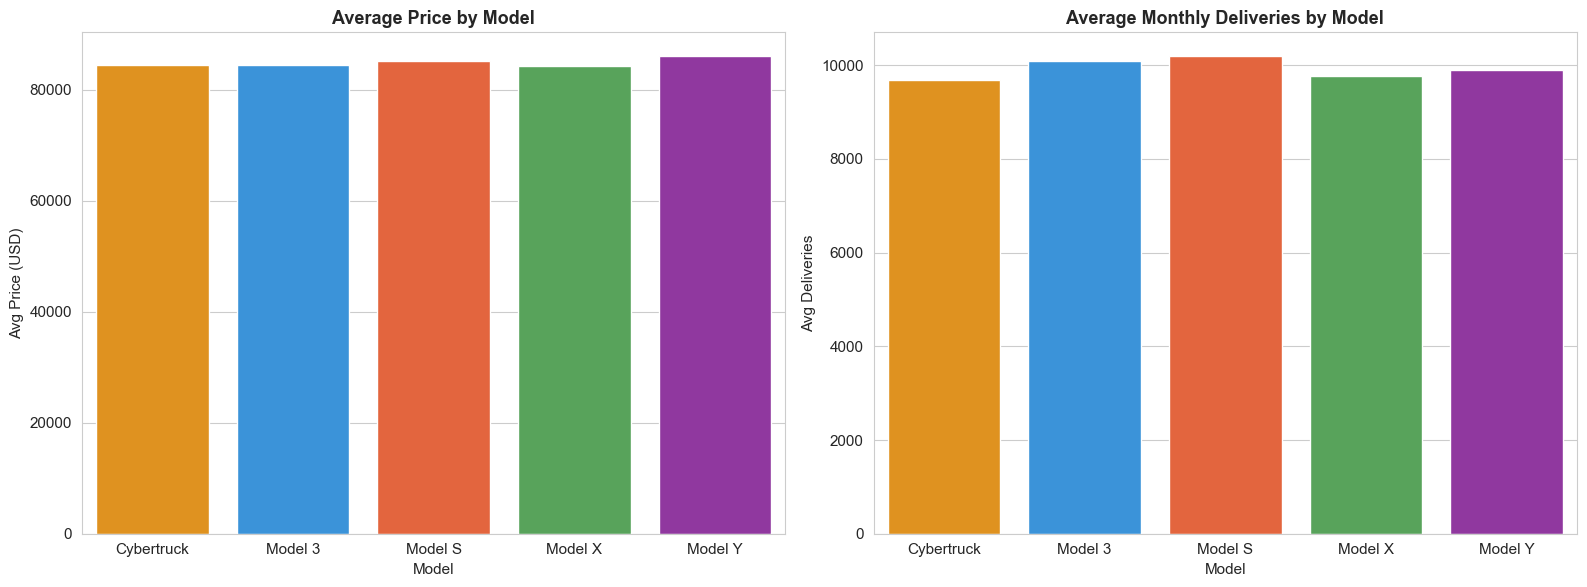

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_palette = {'Model 3': '#2196F3', 'Model S': '#FF5722', 'Model X': '#4CAF50',
                 'Model Y': '#9C27B0', 'Cybertruck': '#FF9800'}

sns.barplot(data=df, x='Model', y='Avg_Price_USD', palette=model_palette,
            errorbar=None, ax=axes[0], order=sorted(df['Model'].unique()))
axes[0].set_title('Average Price by Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Price (USD)')
axes[0].tick_params(axis='x', rotation=0)

sns.barplot(data=df, x='Model', y='Estimated_Deliveries', palette=model_palette,
            errorbar=None, ax=axes[1], order=sorted(df['Model'].unique()))
axes[1].set_title('Average Monthly Deliveries by Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Deliveries')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Scatter plots


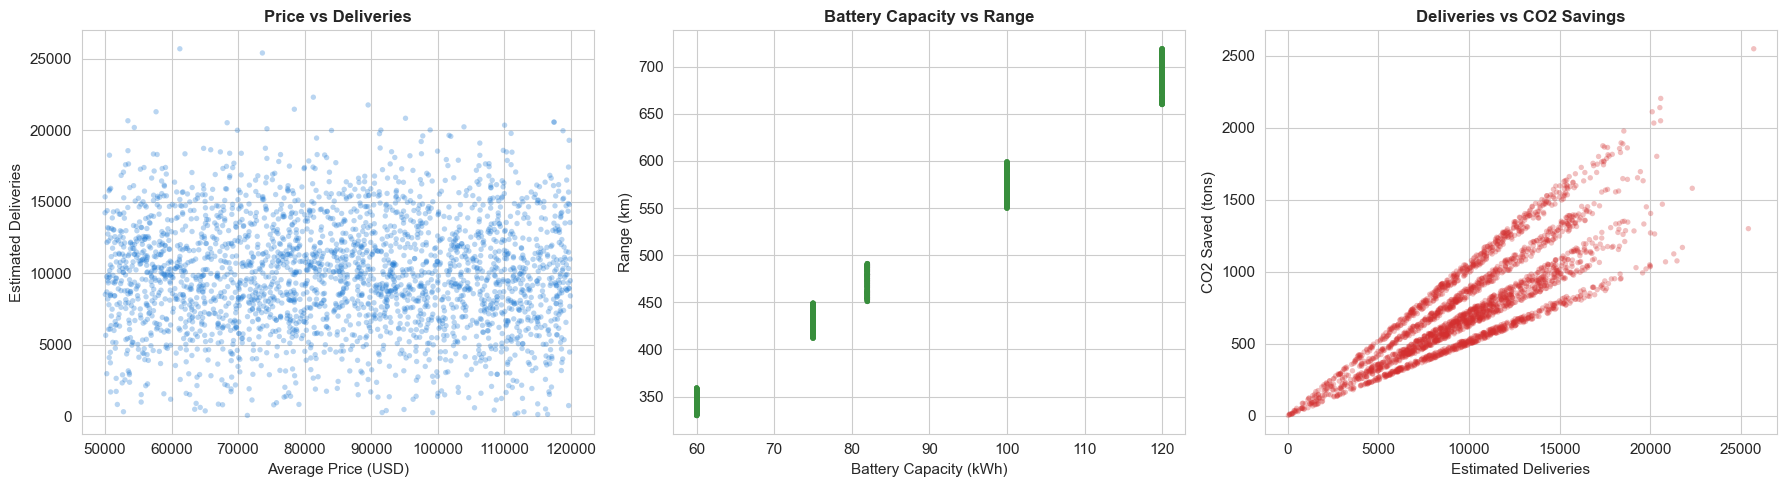

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['Avg_Price_USD'], df['Estimated_Deliveries'], alpha=0.3,
                c='#1976D2', s=15, edgecolors='none')
axes[0].set_xlabel('Average Price (USD)')
axes[0].set_ylabel('Estimated Deliveries')
axes[0].set_title('Price vs Deliveries', fontsize=12, fontweight='bold')

axes[1].scatter(df['Battery_Capacity_kWh'], df['Range_km'], alpha=0.3,
                c='#388E3C', s=15, edgecolors='none')
axes[1].set_xlabel('Battery Capacity (kWh)')
axes[1].set_ylabel('Range (km)')
axes[1].set_title('Battery Capacity vs Range', fontsize=12, fontweight='bold')

axes[2].scatter(df['Estimated_Deliveries'], df['CO2_Saved_tons'], alpha=0.3,
                c='#D32F2F', s=15, edgecolors='none')
axes[2].set_xlabel('Estimated Deliveries')
axes[2].set_ylabel('CO2 Saved (tons)')
axes[2].set_title('Deliveries vs CO2 Savings', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Monthly trend


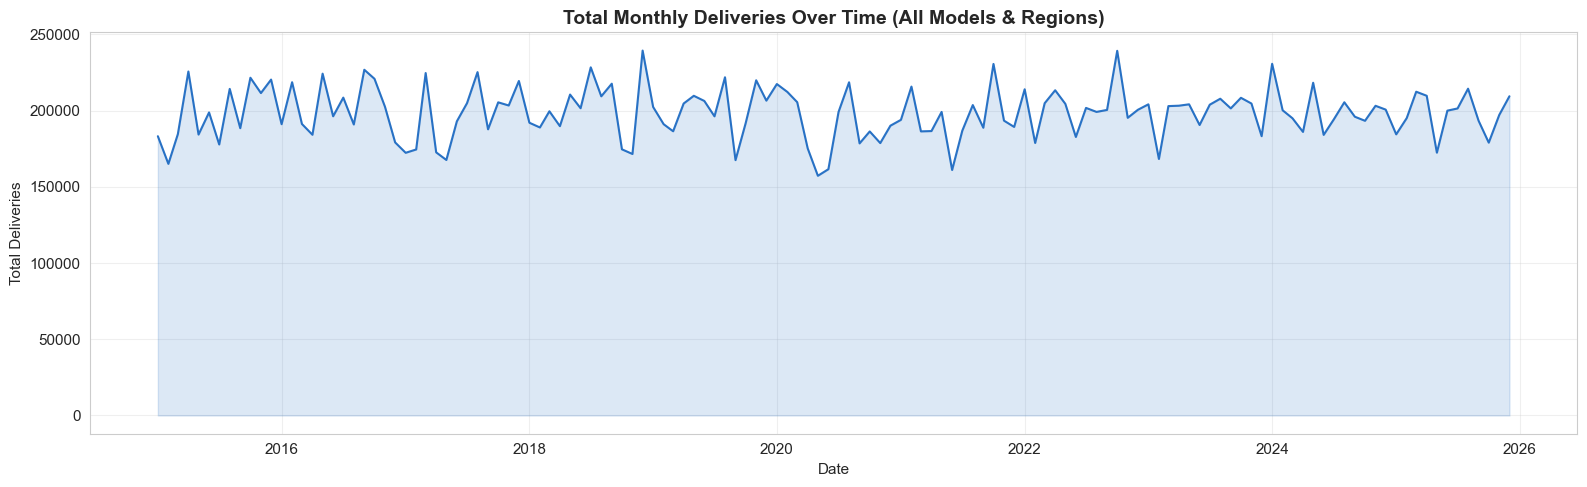

In [ ]:
monthly_total = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
monthly_total.columns = ['Date', 'Total_Deliveries']

plt.figure(figsize=(16, 5))
plt.plot(monthly_total['Date'], monthly_total['Total_Deliveries'], color='#1565C0',
         linewidth=1.5, alpha=0.9)
plt.fill_between(monthly_total['Date'], monthly_total['Total_Deliveries'],
                 alpha=0.15, color='#1565C0')
plt.title('Total Monthly Deliveries Over Time (All Models & Regions)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Feature Engineering


### Encoding techniques
Trying both label encoding and one-hot encoding. Using one-hot for the actual models since the categories aren't ordinal.


In [ ]:
df_feat = df.copy()

# label encoding
le_region = LabelEncoder()
le_model = LabelEncoder()
df_feat['Region_encoded'] = le_region.fit_transform(df_feat['Region'])
df_feat['Model_encoded'] = le_model.fit_transform(df_feat['Model'])

print('Label encoding mapping:')
print(f'  Region: {dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))}')
print(f'  Model:  {dict(zip(le_model.classes_, le_model.transform(le_model.classes_)))}')

Label encoding mapping:
  Region: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
  Model:  {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}


In [ ]:
# dropping label-encoded columns — using one-hot for regression instead
df_feat.drop(columns=['Region_encoded', 'Model_encoded'], inplace=True)

### Time-based and derived features


In [ ]:
df_feat['Quarter'] = df_feat['Date'].dt.quarter
df_feat['HalfYear'] = (df_feat['Month'] <= 6).astype(int)

min_date = df_feat['Date'].min()
df_feat['MonthIndex'] = ((df_feat['Date'].dt.year - min_date.year) * 12 +
                          df_feat['Date'].dt.month - min_date.month)

# derived ratios
df_feat['Delivery_Production_Ratio'] = df_feat['Estimated_Deliveries'] / df_feat['Production_Units']
df_feat['Price_per_kWh'] = df_feat['Avg_Price_USD'] / df_feat['Battery_Capacity_kWh']

print(f'MonthIndex range: {df_feat["MonthIndex"].min()} to {df_feat["MonthIndex"].max()}')

MonthIndex range: 0 to 131


### Lag features and rolling statistics
Computing these per (Region, Model) group so the lags actually make sense.


In [ ]:
df_feat.sort_values(by=['Region', 'Model', 'Date'], inplace=True)

grouped = df_feat.groupby(['Region', 'Model'])

df_feat['Lag_1'] = grouped['Estimated_Deliveries'].shift(1)
df_feat['Lag_3'] = grouped['Estimated_Deliveries'].shift(3)
df_feat['RollingMean_3'] = grouped['Estimated_Deliveries'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)
df_feat['RollingMean_6'] = grouped['Estimated_Deliveries'].transform(
    lambda x: x.rolling(window=6, min_periods=1).mean()
)

# fill initial NaNs from lag with column median
df_feat['Lag_1'] = df_feat['Lag_1'].fillna(df_feat['Lag_1'].median())
df_feat['Lag_3'] = df_feat['Lag_3'].fillna(df_feat['Lag_3'].median())

print(f'Lag/rolling features added. Remaining nulls: {df_feat.isnull().sum().sum()}')

Lag/rolling features added. Remaining nulls: 0


### One-hot encoding and log transform


In [ ]:
df_model = pd.get_dummies(df_feat, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

bool_cols = df_model.select_dtypes(include='bool').columns
for col in bool_cols:
    df_model[col] = df_model[col].astype(int)

df_model['Log_Deliveries'] = np.log1p(df_model['Estimated_Deliveries'])

print(f'Shape after encoding: {df_model.shape}')

Shape after encoding: (2640, 29)


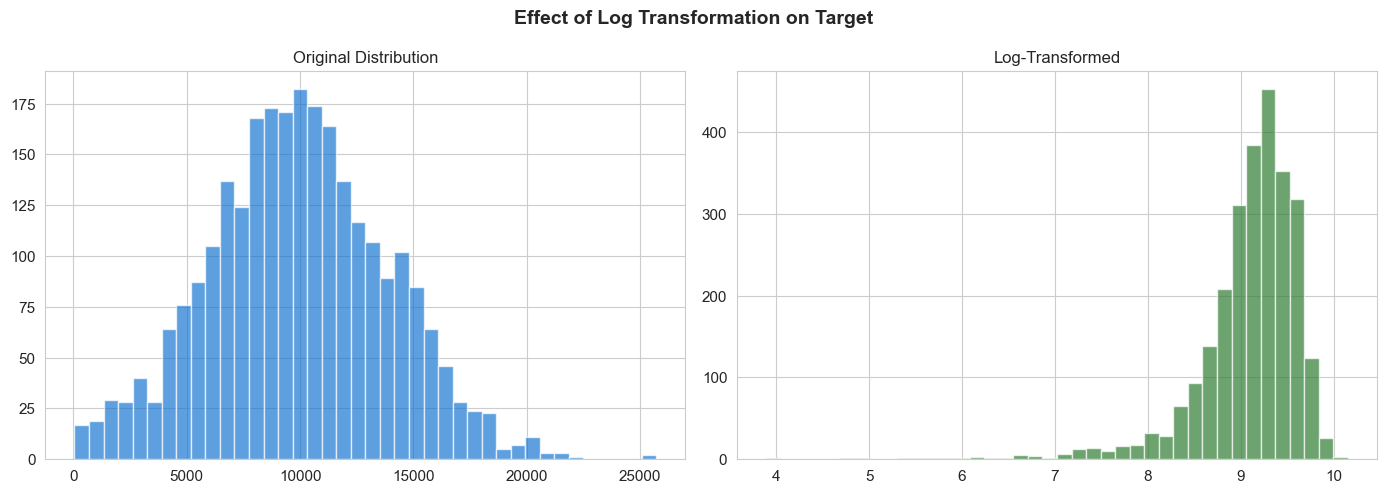

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_model['Estimated_Deliveries'], bins=40, color='#1976D2', alpha=0.7, edgecolor='white')
axes[0].set_title('Original Distribution', fontsize=12)
axes[1].hist(df_model['Log_Deliveries'], bins=40, color='#2E7D32', alpha=0.7, edgecolor='white')
axes[1].set_title('Log-Transformed', fontsize=12)
plt.suptitle('Effect of Log Transformation on Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Leakage Check
Making sure none of our features are just a proxy for the target.


In [ ]:
# checking which features correlate too strongly with the target
target_corr = df_model[numeric_cols + ['Delivery_Production_Ratio', 'Lag_1', 'RollingMean_3']].corrwith(
    df_model['Estimated_Deliveries']
).sort_values(ascending=False)

print('Correlation with target (Estimated_Deliveries):')
print(target_corr.round(3))

# Production_Units has very high correlation — basically a proxy.
# keeping it in but worth noting it inflates R² scores.

Correlation with target (Estimated_Deliveries):
Estimated_Deliveries         1.000
Production_Units             0.994
CO2_Saved_tons               0.837
RollingMean_3                0.563
Delivery_Production_Ratio    0.001
Charging_Stations            0.001
Range_km                    -0.007
Battery_Capacity_kWh        -0.008
Lag_1                       -0.008
Avg_Price_USD               -0.028
dtype: float64


## 5. Regression Modeling


In [ ]:
drop_cols = ['Estimated_Deliveries', 'Log_Deliveries', 'Date', 'Year', 'Month']
feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols].copy()
y = df_model['Estimated_Deliveries'].copy()

# drop any rows with NaN
valid_mask = X.notna().all(axis=1) & y.notna()
X = X[valid_mask]
y = y[valid_mask]

print(f'Feature matrix: {X.shape}')
print(f'Any NaN? {X.isnull().any().any()}')

Feature matrix: (2640, 24)
Any NaN? False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 2112, Test: 528


### Feature scaling


In [ ]:
# scaling — fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    train_preds = model.predict(X_tr)
    test_preds = model.predict(X_te)

    train_r2 = r2_score(y_tr, train_preds)
    test_r2 = r2_score(y_te, test_preds)
    mae = mean_absolute_error(y_te, test_preds)
    rmse = np.sqrt(mean_squared_error(y_te, test_preds))

    print(f'{name}:')
    print(f'  Train R² = {train_r2:.4f}  |  Test R² = {test_r2:.4f}  |  Gap = {train_r2 - test_r2:.4f}')
    print(f'  MAE = {mae:.2f}  |  RMSE = {rmse:.2f}')
    print()

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': test_r2,
            'Train_R2': train_r2, 'Predictions': test_preds, 'Fitted': model}

In [ ]:
results = []

# Linear Regression
lr = LinearRegression()
results.append(evaluate_model('Linear Regression', lr, X_train_scaled, X_test_scaled, y_train, y_test))

# Ridge (L2 regularization)
ridge = Ridge(alpha=1.0)
results.append(evaluate_model('Ridge (L2)', ridge, X_train_scaled, X_test_scaled, y_train, y_test))

# Lasso (L1 regularization)
lasso = Lasso(alpha=1.0)
results.append(evaluate_model('Lasso (L1)', lasso, X_train_scaled, X_test_scaled, y_train, y_test))

# Decision Tree
dt = DecisionTreeRegressor(max_depth=12, min_samples_split=10, random_state=42)
results.append(evaluate_model('Decision Tree', dt, X_train, X_test, y_train, y_test))

# Random Forest
rf = RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_split=5,
                           random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test))

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                subsample=0.8, random_state=42)
results.append(evaluate_model('Gradient Boosting', gb, X_train, X_test, y_train, y_test))

Linear Regression:
  Train R² = 0.9984  |  Test R² = 0.9985  |  Gap = -0.0000
  MAE = 107.78  |  RMSE = 152.48

Ridge (L2):
  Train R² = 0.9984  |  Test R² = 0.9985  |  Gap = -0.0000
  MAE = 107.62  |  RMSE = 152.39



Lasso (L1):
  Train R² = 0.9984  |  Test R² = 0.9985  |  Gap = -0.0000
  MAE = 107.61  |  RMSE = 152.49



Decision Tree:
  Train R² = 0.9995  |  Test R² = 0.9979  |  Gap = 0.0016
  MAE = 124.84  |  RMSE = 177.59



Random Forest:
  Train R² = 0.9997  |  Test R² = 0.9982  |  Gap = 0.0015
  MAE = 74.67  |  RMSE = 167.22



Gradient Boosting:
  Train R² = 1.0000  |  Test R² = 0.9988  |  Gap = 0.0012
  MAE = 51.35  |  RMSE = 135.17



### Bias-Variance tradeoff — overfitting check
If train R² is way higher than test R², the model is memorizing instead of learning.


In [ ]:
# train vs test R² — checking for overfitting
bias_var_df = pd.DataFrame([{
    'Model': r['Model'],
    'Train R²': r['Train_R2'],
    'Test R²': r['R2'],
    'Gap': r['Train_R2'] - r['R2'],
    'Status': 'Overfitting' if (r['Train_R2'] - r['R2']) > 0.05
             else ('Underfitting' if r['R2'] < 0.5 else 'Good fit')
} for r in results]).round(4)

bias_var_df

,Model,Train R²,Test R²,Gap,Status
0,Linear Regression,0.9984,0.9985,-0.0000,Good fit
1,Ridge (L2),0.9984,0.9985,-0.0000,Good fit
2,Lasso (L1),0.9984,0.9985,-0.0000,Good fit
3,Decision Tree,0.9995,0.9979,0.0016,Good fit
4,Random Forest,0.9997,0.9982,0.0015,Good fit
5,Gradient Boosting,1.0000,0.9988,0.0012,Good fit


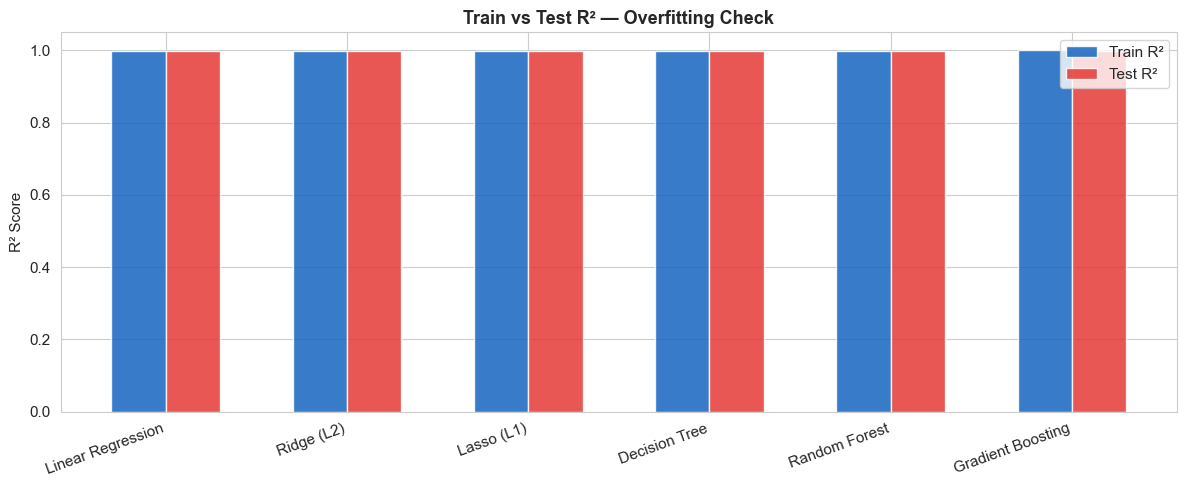

In [ ]:
# visualizing train vs test scores
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(bias_var_df))

ax.bar(x_pos - 0.15, bias_var_df['Train R²'], 0.3, color='#1565C0', alpha=0.85, label='Train R²')
ax.bar(x_pos + 0.15, bias_var_df['Test R²'], 0.3, color='#E53935', alpha=0.85, label='Test R²')

ax.set_xticks(x_pos)
ax.set_xticklabels(bias_var_df['Model'], rotation=20, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('Train vs Test R² — Overfitting Check', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Model comparison


In [ ]:
comparison_df = pd.DataFrame([{'Model': r['Model'], 'MAE': r['MAE'],
                                'RMSE': r['RMSE'], 'R²': r['R2']} for r in results])
comparison_df = comparison_df.sort_values('R²', ascending=False).reset_index(drop=True)
comparison_df

,Model,MAE,RMSE,R²
0,Gradient Boosting,51.353043,135.165485,0.998810
1,Ridge (L2),107.623985,152.392800,0.998487
2,Linear Regression,107.780801,152.476544,0.998486
3,Lasso (L1),107.606554,152.488985,0.998486
4,Random Forest,74.671868,167.215804,0.998179
5,Decision Tree,124.836621,177.593171,0.997946


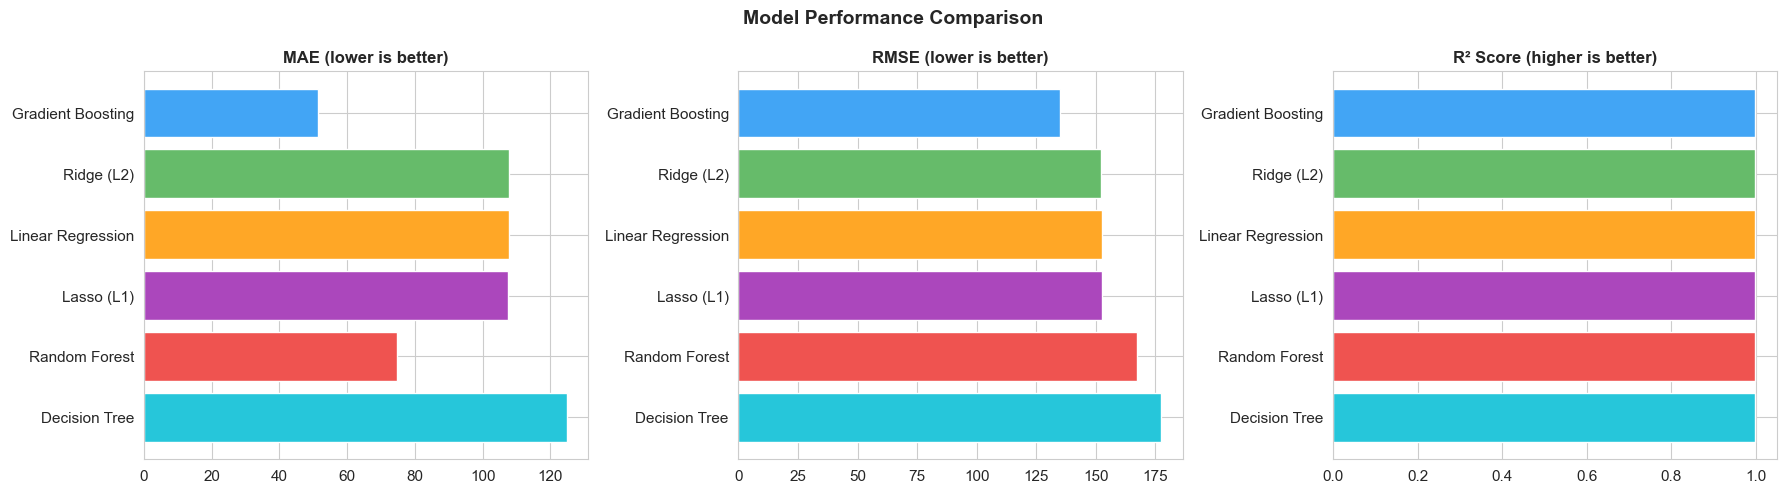

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_colors = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC', '#EF5350', '#26C6DA']
model_names = comparison_df['Model'].tolist()

axes[0].barh(model_names, comparison_df['MAE'], color=bar_colors[:len(model_names)])
axes[0].set_title('MAE (lower is better)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh(model_names, comparison_df['RMSE'], color=bar_colors[:len(model_names)])
axes[1].set_title('RMSE (lower is better)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

axes[2].barh(model_names, comparison_df['R²'], color=bar_colors[:len(model_names)])
axes[2].set_title('R² Score (higher is better)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()
axes[2].set_xlim(0, 1.05)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature importance


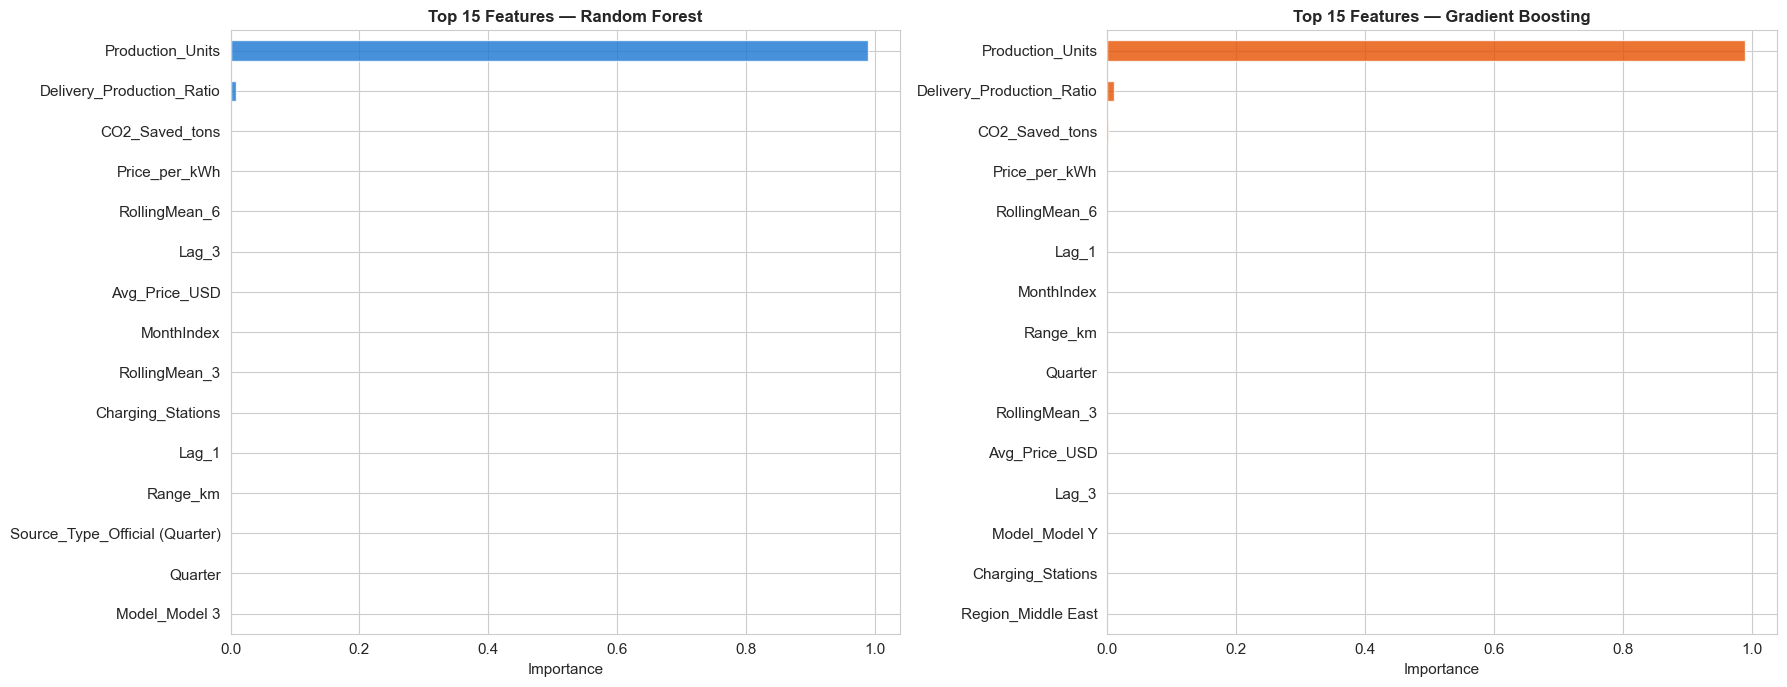

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

feat_col_list = list(X.columns)

for idx, (name, model_obj) in enumerate([('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = model_obj.feature_importances_
    feat_imp = pd.Series(importances, index=feat_col_list).sort_values(ascending=True)
    top15 = feat_imp.tail(15)
    top15.plot(kind='barh', ax=axes[idx], color='#1976D2' if idx == 0 else '#E65100', alpha=0.8)
    axes[idx].set_title(f'Top 15 Features — {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### Actual vs Predicted


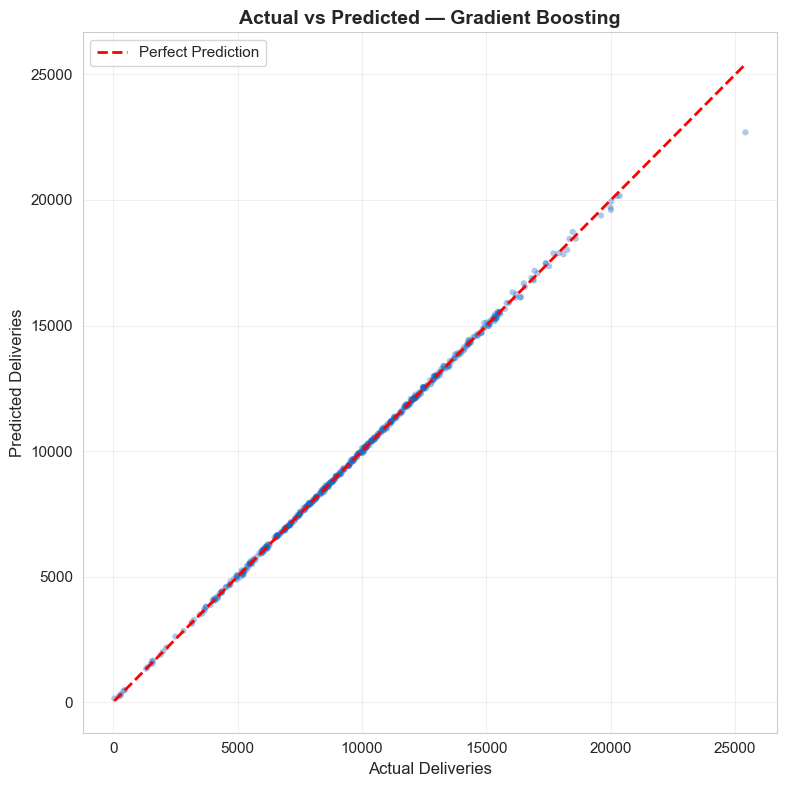

In [ ]:
best_result = max(results, key=lambda x: x['R2'])
best_preds = best_result['Predictions']
best_name = best_result['Model']

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.35, s=20, c='#1565C0', edgecolors='none')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Deliveries', fontsize=12)
plt.ylabel('Predicted Deliveries', fontsize=12)
plt.title(f'Actual vs Predicted — {best_name}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Cross Validation
Single train-test split can be misleading. Running 5-fold CV to get more stable scores.


In [ ]:
# 5-fold cross validation on the top models
cv_models = {
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=1.0))]),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=6, random_state=42)
}

print('5-Fold Cross Validation Results:')
print('-' * 50)
for name, model in cv_models.items():
    scores = cross_val_score(model, X.values, y.values, cv=5, scoring='r2')
    print(f'{name:20s}  mean R²={scores.mean():.4f}  std={scores.std():.4f}  folds={scores.round(4)}')

5-Fold Cross Validation Results:
--------------------------------------------------
Ridge                 mean R²=0.9984  std=0.0001  folds=[0.9984 0.9983 0.9985 0.9982 0.9985]
Lasso                 mean R²=0.9984  std=0.0001  folds=[0.9984 0.9983 0.9985 0.9982 0.9985]


Random Forest         mean R²=0.9984  std=0.0006  folds=[0.998  0.9987 0.9991 0.9987 0.9975]


Gradient Boosting     mean R²=0.9990  std=0.0008  folds=[0.9994 0.9995 0.9996 0.9992 0.9975]


## 7. Hyperparameter Tuning


In [ ]:
print(f'Tuning best model: {best_name}')
print(f'Current R²: {best_result["R2"]:.4f}')

Tuning best model: Gradient Boosting
Current R²: 0.9988


In [ ]:
if 'Random Forest' in best_name:
    tuning_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [10, 15, 20, 25, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.5]
    }
elif 'Gradient' in best_name:
    tuning_model = GradientBoostingRegressor(random_state=42)
    param_grid = {
        'n_estimators': [150, 200, 300, 400],
        'max_depth': [4, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.15],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
else:
    tuning_model = GradientBoostingRegressor(random_state=42)
    param_grid = {
        'n_estimators': [150, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0]
    }

random_search = RandomizedSearchCV(
    estimator=tuning_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f'\nBest CV R²: {random_search.best_score_:.4f}')
print(f'\nBest params:')
for param, val in random_search.best_params_.items():
    print(f'  {param}: {val}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits



Best CV R²: 0.9988

Best params:
  subsample: 0.7
  n_estimators: 400
  min_samples_split: 10
  min_samples_leaf: 1
  max_depth: 6
  learning_rate: 0.1


In [ ]:
tuned_model = random_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

print(f'{"Metric":<10} {"Before":>12} {"After":>12} {"Change":>12}')
print('-'*50)
print(f'{"MAE":<10} {best_result["MAE"]:>12.2f} {tuned_mae:>12.2f} {tuned_mae - best_result["MAE"]:>+12.2f}')
print(f'{"RMSE":<10} {best_result["RMSE"]:>12.2f} {tuned_rmse:>12.2f} {tuned_rmse - best_result["RMSE"]:>+12.2f}')
print(f'{"R²":<10} {best_result["R2"]:>12.4f} {tuned_r2:>12.4f} {tuned_r2 - best_result["R2"]:>+12.4f}')

Metric           Before        After       Change
--------------------------------------------------
MAE               51.35        47.48        -3.87
RMSE             135.17        99.09       -36.08
R²               0.9988       0.9994      +0.0006


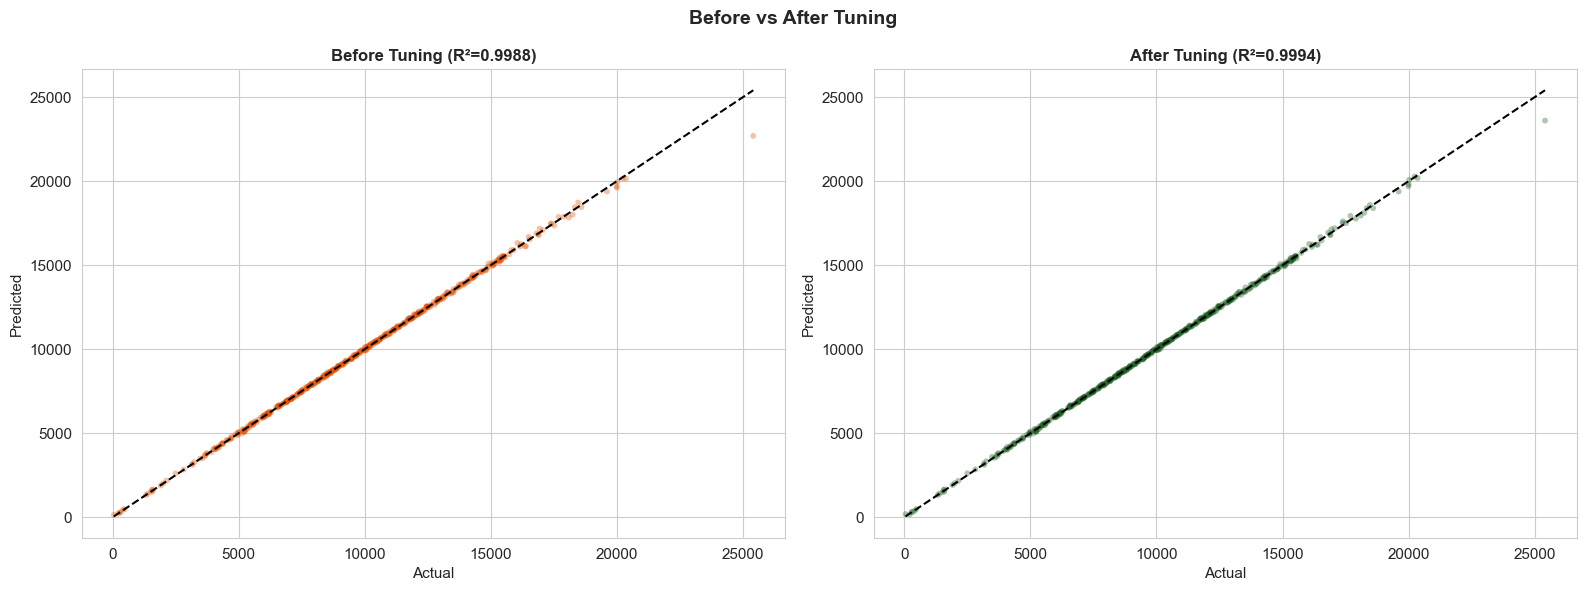

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, best_preds, alpha=0.35, s=18, c='#E65100', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
axes[0].set_title(f'Before Tuning (R²={best_result["R2"]:.4f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test, tuned_preds, alpha=0.35, s=18, c='#1B5E20', edgecolors='none')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
axes[1].set_title(f'After Tuning (R²={tuned_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.suptitle('Before vs After Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Residual analysis


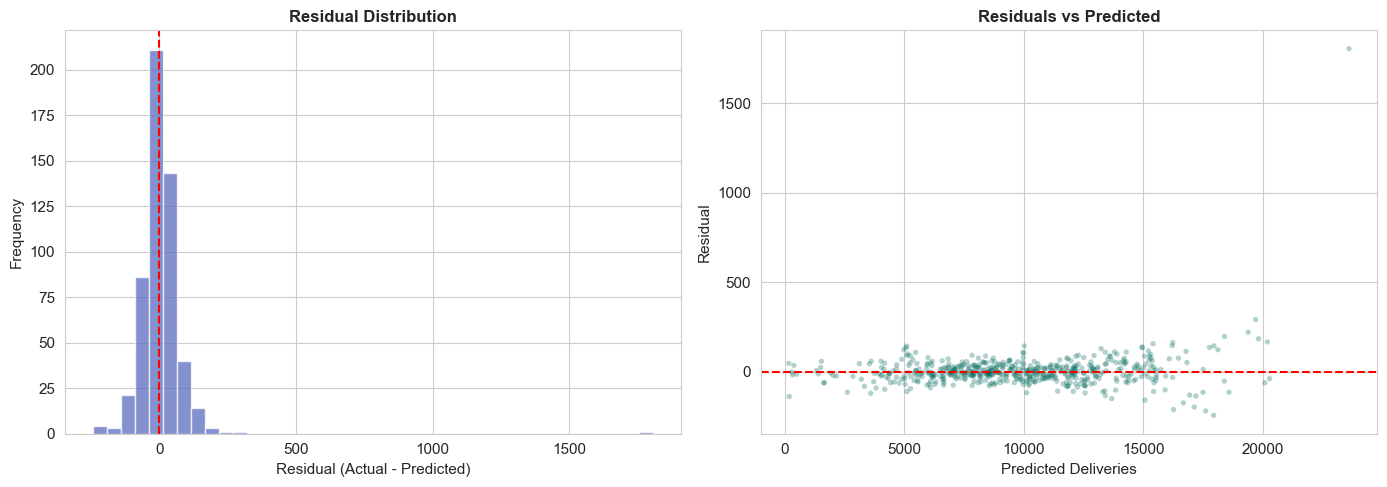

Mean: 3.87, Std: 99.01


In [ ]:
residuals = y_test - tuned_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=40, color='#5C6BC0', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(tuned_preds, residuals, alpha=0.3, s=15, c='#00695C', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Deliveries')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f'Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f}')

## 8. Time Series Forecasting


In [ ]:
# aggregate to monthly time series
ts_data = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts_data.columns = ['Date', 'Deliveries']
ts_data.set_index('Date', inplace=True)
ts_data = ts_data.asfreq('MS')
ts_data['Deliveries'] = ts_data['Deliveries'].ffill()

print(f'Time series: {ts_data.shape[0]} months')
print(f'{ts_data.index.min()} to {ts_data.index.max()}')

Time series: 132 months
2015-01-01 00:00:00 to 2025-12-01 00:00:00


### Stationarity test


In [ ]:
adf_result = adfuller(ts_data['Deliveries'])

print('Augmented Dickey-Fuller Test:')
print(f'  Test Statistic: {adf_result[0]:.4f}')
print(f'  p-value:        {adf_result[1]:.4f}')
for key, val in adf_result[4].items():
    print(f'    {key}: {val:.4f}')

if adf_result[1] < 0.05:
    print('\n=> Stationary (p < 0.05)')
else:
    print('\n=> Non-stationary — differencing needed')

Augmented Dickey-Fuller Test:
  Test Statistic: -8.8810
  p-value:        0.0000
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788

=> Stationary (p < 0.05)


### Time series decomposition


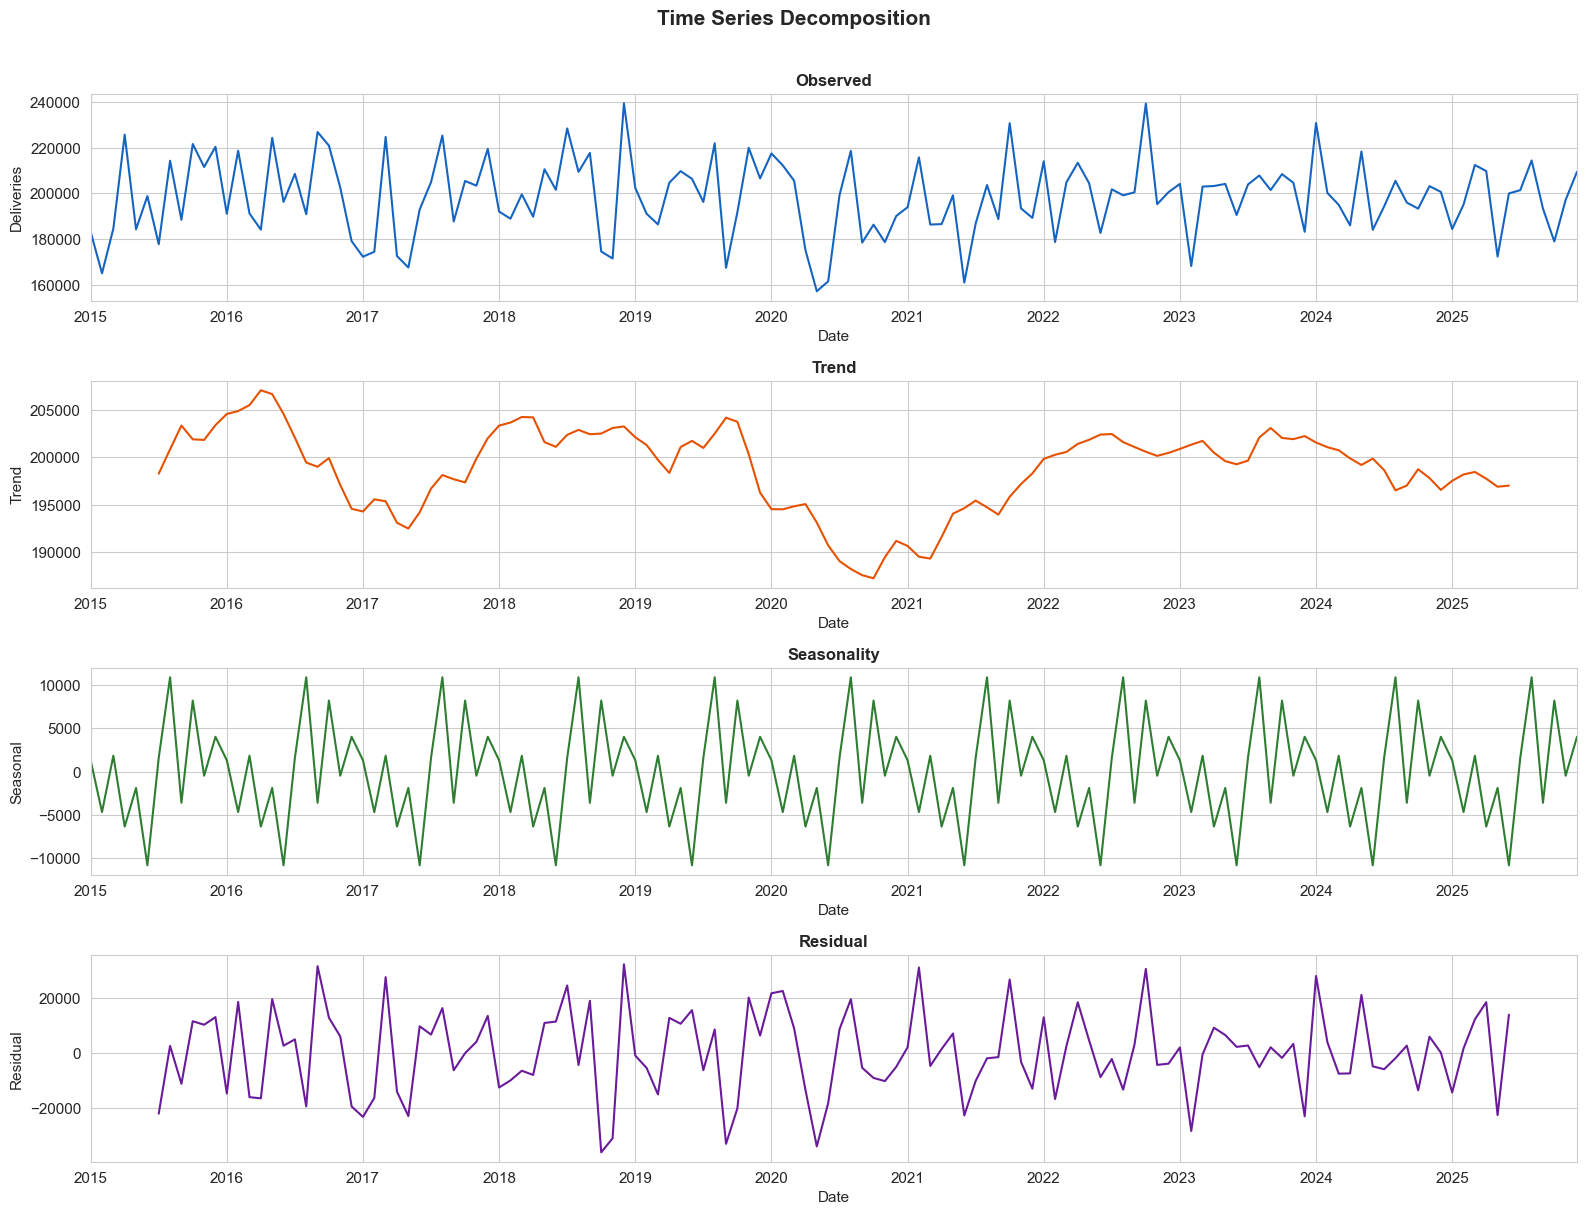

In [ ]:
decomposition = seasonal_decompose(ts_data['Deliveries'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

decomposition.observed.plot(ax=axes[0], color='#1565C0')
axes[0].set_title('Observed', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Deliveries')

decomposition.trend.plot(ax=axes[1], color='#E65100')
axes[1].set_title('Trend', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='#2E7D32')
axes[2].set_title('Seasonality', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], color='#6A1B9A')
axes[3].set_title('Residual', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')

plt.suptitle('Time Series Decomposition', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Chronological split
Can't do random splits on time series — training on 2015-2023, testing on 2024-2025.


In [ ]:
train_ts = ts_data[ts_data.index < '2024-01-01']
test_ts = ts_data[ts_data.index >= '2024-01-01']

print(f'Train: {train_ts.index.min().strftime("%Y-%m")} to {train_ts.index.max().strftime("%Y-%m")} ({len(train_ts)} months)')
print(f'Test:  {test_ts.index.min().strftime("%Y-%m")} to {test_ts.index.max().strftime("%Y-%m")} ({len(test_ts)} months)')

Train: 2015-01 to 2023-12 (108 months)
Test:  2024-01 to 2025-12 (24 months)


### SARIMAX


In [ ]:
sarima_model = SARIMAX(
    train_ts['Deliveries'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print(sarima_fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0360      0.200      0.180      0.857      -0.355       0.427
ma.L1         -0.7123      0.109     -6.526      0.000      -0.926      -0.498
ar.S.L12      -0.0692      0.269     -0.257      0.797      -0.597       0.458
ma.S.L12      -0.4069      0.266     -1.532      0.126      -0.928       0.114
sigma2      7.202e+08   6.84e-11   1.05e+19      0.000     7.2e+08     7.2e+08


In [ ]:
n_forecast = len(test_ts)
forecast_result = sarima_fit.get_forecast(steps=n_forecast)
forecast_values = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int(alpha=0.05)

forecast_values.index = test_ts.index
confidence_intervals.index = test_ts.index

In [ ]:
ts_mae = mean_absolute_error(test_ts['Deliveries'], forecast_values)
ts_rmse = np.sqrt(mean_squared_error(test_ts['Deliveries'], forecast_values))
ts_mape = np.mean(np.abs((test_ts['Deliveries'] - forecast_values) / test_ts['Deliveries'])) * 100

print(f'MAE:  {ts_mae:.2f}')
print(f'RMSE: {ts_rmse:.2f}')
print(f'MAPE: {ts_mape:.2f}%')

MAE:  13435.59
RMSE: 16570.11
MAPE: 6.80%


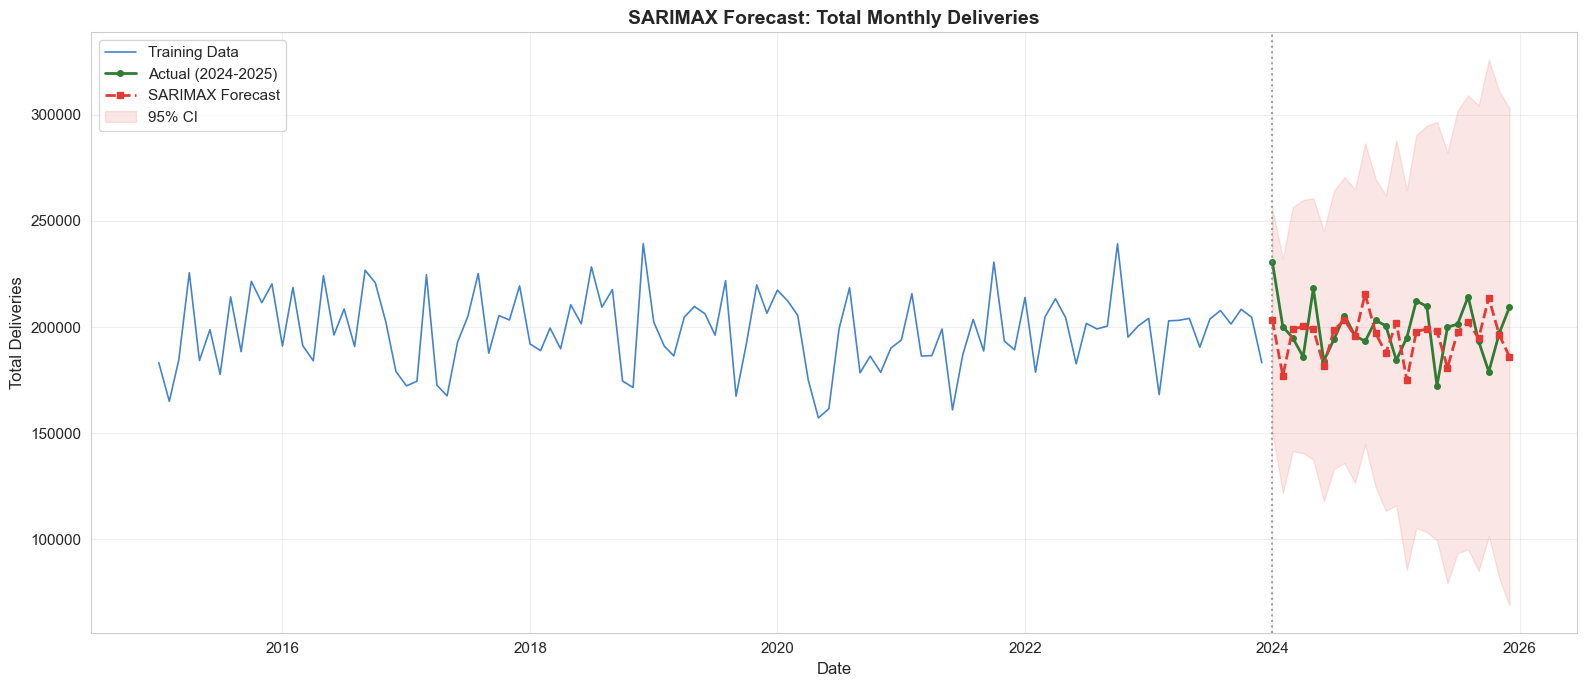

In [ ]:
plt.figure(figsize=(16, 7))

plt.plot(train_ts.index, train_ts['Deliveries'], color='#1565C0', linewidth=1.2,
         label='Training Data', alpha=0.8)
plt.plot(test_ts.index, test_ts['Deliveries'], color='#2E7D32', linewidth=2,
         label='Actual (2024-2025)', marker='o', markersize=4)
plt.plot(test_ts.index, forecast_values, color='#E53935', linewidth=2,
         label='SARIMAX Forecast', linestyle='--', marker='s', markersize=4)

plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='#E53935', alpha=0.12, label='95% CI')

plt.axvline(x=pd.Timestamp('2024-01-01'), color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
plt.title('SARIMAX Forecast: Total Monthly Deliveries', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Deliveries', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Forecast comparison


In [ ]:
forecast_comparison = pd.DataFrame({
    'Month': test_ts.index.strftime('%Y-%m'),
    'Actual': test_ts['Deliveries'].values,
    'Forecast': forecast_values.values.round(0),
    'Error': (test_ts['Deliveries'].values - forecast_values.values).round(0),
    'Error_%': ((test_ts['Deliveries'].values - forecast_values.values) / test_ts['Deliveries'].values * 100).round(2)
})

forecast_comparison

,Month,Actual,Forecast,Error,Error_%
0,2024-01,230697,203291.0,27406.0,11.88
1,2024-02,200193,177013.0,23180.0,11.58
2,2024-03,194961,199008.0,-4047.0,-2.08
3,2024-04,186011,200272.0,-14261.0,-7.67
4,2024-05,218256,199101.0,19155.0,8.78
5,2024-06,184061,181606.0,2455.0,1.33
6,2024-07,194250,198744.0,-4494.0,-2.31
7,2024-08,205440,203294.0,2146.0,1.04
8,2024-09,195968,195709.0,259.0,0.13
9,2024-10,193298,215658.0,-22360.0,-11.57


### Takeaways
- Tree-based models (RF, GB) beat linear models here — the relationships in the data aren't purely linear.
- Lag and rolling features helped, but Production_Units dominates feature importance (which makes sense — you deliver what you produce).
- SARIMAX picks up the overall growth trend but struggles with month-to-month noise, MAPE reflects that.
